In [ ]:
#Reference
#https://github.com/fnusatvik07/agent-builder-thinkinginglanggraph/blob/main/workbooks/12_agents_and_toolnode.ipynb

This last workbook moves to agents: systems that decide their own path through tools you provide. An **agent** is just an LLM in a loop with tools, and the LLM decides when to stop.


In [1]:
!pip install langchain langchain-groq langgraph python-dotenv ipython --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 137.5/137.5 kB 6.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 49.3 MB/s eta 0:00:00


In [2]:
import os
from dotenv import load_dotenv
load_dotenv('/content/.env.txt')
print("Keys loaded:", "GROQ_API_KEY")

Keys loaded: GROQ_API_KEY


In [3]:
import os, operator
from pathlib import Path
from typing import Annotated, List, TypedDict
from typing_extensions import Literal

from pydantic import BaseModel, Field
from langchain.messages import HumanMessage, SystemMessage
from langgraph.graph import StateGraph, START, END
#from langgraph.types import Send

In [4]:
from pathlib import Path
from IPython.display import Image, display, Markdown

OUT = Path("graph_out_orchestrator")
OUT.mkdir(exist_ok=True)

def save_graph(app, name):
    graph = app.get_graph()

    (OUT / f"{name}.mmd").write_text(graph.draw_mermaid())

    try:
        (OUT / f"{name}.png").write_bytes(graph.draw_mermaid_png())
        print(f"Saved: {name}.png")
    except Exception:
        print("PNG generation failed")

def show_graph(name):
    png = OUT / f"{name}.png"

    if png.exists():
        display(Image(filename=png))
    else:
        display(Markdown(f"Open `graph_out/{name}.mmd` in mermaid.live"))

In [6]:
# Initialize Groq model
from langchain.chat_models import init_chat_model


llm = init_chat_model(
    "groq:llama-3.3-70b-versatile",
    temperature=0
)

print("llm")

llm


**The tools**
Three trivial arithmetic tools. @tool turns each function into a tool the LLM can call. The docstring and type hints become the schema.

In [10]:
from langchain.messages import ToolMessage
#from langgraph.graph import StateGraph, MessagesState, START, END
from langgraph.graph import MessagesState

In [11]:
from langchain.tools import tool

In [12]:
@tool
def multiply(a: int, b: int) -> int:
    """Multiply a and b."""
    return a * b

@tool
def add(a: int, b: int) -> int:
    """Add a and b."""
    return a + b

@tool
def divide(a: int, b: int) -> float:
    """Divide a by b."""
    return a / b

tools = [add, multiply, divide]
tools_by_name = {t.name: t for t in tools}
llm_with_tools = llm.bind_tools(tools)


**Custom agent loop (Graph API)**
Two nodes. llm_call invokes the model. tool_node runs any tool calls. A conditional edge decides whether to loop or stop

In [13]:
'''
def llm_call(state: MessagesState):
    return {
        "messages": [
            llm_with_tools.invoke(
                [SystemMessage(content="You are a helpful assistant performing arithmetic. Use the tools.")]
                + state["messages"]
            )
        ]
    }

def tool_node(state: dict):
    results = []
    for tc in state["messages"][-1].tool_calls:
        t = tools_by_name[tc["name"]]
        observation = t.invoke(tc["args"])
        print(f"[tool] {tc['name']}({tc['args']}) -> {observation}")
        results.append(ToolMessage(content=str(observation), tool_call_id=tc["id"]))
    return {"messages": results}

def should_continue(state: MessagesState) -> Literal["tool_node", "__end__"]:
    last = state["messages"][-1]
    if getattr(last, "tool_calls", None):
        return "tool_node"
    return END
    '''


In [15]:
import logging
logger = logging.getLogger(__name__)

SYSTEM_PROMPT = "You are a helpful assistant performing arithmetic. Use the tools."


def llm_call(state: MessagesState) -> dict:
    response = llm_with_tools.invoke(
        [SystemMessage(content=SYSTEM_PROMPT)] + state["messages"]
    )
    return {"messages": [response]}


def tool_node(state: MessagesState) -> dict:
    results = []
    for tc in state["messages"][-1].tool_calls:
        tool = tools_by_name[tc["name"]]
        observation = tool.invoke(tc["args"])
        logger.debug("Tool: %s | Args: %s | Result: %s", tc["name"], tc["args"], observation)
        results.append(ToolMessage(content=str(observation), tool_call_id=tc["id"]))
    return {"messages": results}


def should_continue(state: MessagesState) -> Literal["tool_node", "__end__"]:
    last_message = state["messages"][-1]
    if getattr(last_message, "tool_calls", None):
        return "tool_node"
    return END

'''get the value of an object's attribute dynamically.'''

"get the value of an object's attribute dynamically."

Saved: 12_agent_custom.png


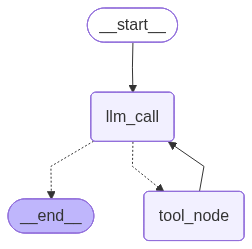

In [16]:
builder = StateGraph(MessagesState)
builder.add_node("llm_call", llm_call)
builder.add_node("tool_node", tool_node)

builder.add_edge(START, "llm_call")
builder.add_conditional_edges("llm_call", should_continue, ["tool_node", END])
builder.add_edge("tool_node", "llm_call")

agent = builder.compile()
save_graph(agent, "12_agent_custom")
show_graph("12_agent_custom")


In [17]:
messages = [HumanMessage(content="Add 3 and 4, then multiply the result by 10.")]
result = agent.invoke({"messages": messages})
print("\n--- conversation ---")
for m in result["messages"]:
    m.pretty_print()



--- conversation ---
================================ Human Message =================================

Add 3 and 4, then multiply the result by 10.
================================== Ai Message ==================================
Tool Calls:
  add (q79txwhbe)
 Call ID: q79txwhbe
  Args:
    a: 3
    b: 4
  multiply (rm0y2f2d9)
 Call ID: rm0y2f2d9
  Args:
    a: 7
    b: 10
================================= Tool Message =================================

7
================================= Tool Message =================================

70
================================== Ai Message ==================================

The result of adding 3 and 4 is 7, then multiplying 7 by 10 results in 70.


In [20]:
result = agent.invoke({
    "messages": [HumanMessage(content="Add 3 and 4,then multiply the result by 10")]
})
print("\n--- conversation ---")
for m in result["messages"]:
    m.pretty_print()


--- conversation ---
================================ Human Message =================================

Add 3 and 4,then multiply the result by 10
================================== Ai Message ==================================
Tool Calls:
  add (a41nwfg8v)
 Call ID: a41nwfg8v
  Args:
    a: 3
    b: 4
  multiply (h5420r73r)
 Call ID: h5420r73r
  Args:
    a: 7
    b: 10
================================= Tool Message =================================

7
================================= Tool Message =================================

70
================================== Ai Message ==================================

The result of adding 3 and 4 is 7, then multiplying 7 by 10 results in 70.


In [ ]:
#The safe_eval using ast only allows numbers and the 5 basic math operators — nothing else can
#sneak through. This is the standard pattern for safe math evaluation in Python




In [ ]:
# https://www.linkedin.com/posts/jolly-g-b7672a189_ai-agents-llm-share-7468208337881456640-W-5X/?utm_source=share&utm_medium=member_desktop&rcm=ACoAACxskAoBYFvmFLAic6SaIJU7T8EvApag3U0

**Complete WorkFlow**

```text
Your Python @tool function
 ↓
LangChain inspects function
 ↓
LangChain creates JSON Schema
 ↓
LangChain sends:
 - User message
 - Tool schema
to Groq API
 ↓
─────────────────────────────
Inside Groq
─────────────────────────────
Groq API receives request
 ↓
Groq validates tool schema
 ↓
Schema valid?
 ├─ NO → ❌ Error returned
 │
 └─ YES
 ↓
Schema passed to LLM
 ↓
LLM reads:
 - User question
 - Available tools
 - Tool schema
 ↓
LLM decides:
 "Need a tool?"
 ↓
 ├─ NO
 │  ↓
 │ Generate normal answer
 │
 └─ YES
 ↓
LLM generates tool call
example:
{
 "name":"add",
 "arguments":{
 "a":10,
 "b":20
 }
}
 ↓
Groq validates generated tool call
against schema
 ↓
Tool call valid?
 ├─ NO
 │  ↓
 │ ❌ Error returned
 │
 └─ YES
 ↓
Tool call sent back to LangChain
─────────────────────────────
Back in LangChain
─────────────────────────────
LangChain receives tool call
 ↓
Parses arguments
 ↓
Optional validation
(Pydantic / Tool schema)
 ↓
Tool executes in Python
add(10,20)
 ↓
Result = 30
 ↓
LangChain creates ToolMessage
 ↓
Tool result sent back to Groq
 ↓
LLM sees:
 Tool output = 30
 ↓
LLM generates final response
 ↓
LangChain receives response
 ↓
User sees answer
```

**Use the prebuilt ToolNode**

In **production** use the prebuilt ToolNode. It handles parallel tool calls, errors, and state injection automatically.

In [23]:
from langgraph.prebuilt import ToolNode

In [24]:
import logging
import ast
import operator
logger = logging.getLogger(__name__)

SYSTEM_PROMPT = "You are a helpful research assistant."

# --- Tools ---

@tool
def search(query: str) -> str:
    """Search for information."""
    logger.debug("Search query: %s", query)
    return f"Mocked results for: {query}"

@tool
def calculator(expression: str) -> str:
    """Safely evaluate a math expression like '2 * (3 + 4)'."""
    try:
        result = safe_eval(expression)
        logger.debug("Calculator: %s = %s", expression, result)
        return str(result)
    except Exception as e:
        logger.warning("Calculator error for '%s': %s", expression, e)
        return f"Error: {e}"


# --- Safe eval (never use raw eval in production) ---

SAFE_OPERATORS = {
    ast.Add: operator.add,
    ast.Sub: operator.sub,
    ast.Mult: operator.mul,
    ast.Div: operator.truediv,
    ast.Pow: operator.pow,
    ast.USub: operator.neg,
}

def safe_eval(expression: str) -> float:
    def _eval(node):
        if isinstance(node, ast.Constant):
            return node.value
        if isinstance(node, ast.BinOp):
            return SAFE_OPERATORS[type(node.op)](_eval(node.left), _eval(node.right))
        if isinstance(node, ast.UnaryOp):
            return SAFE_OPERATORS[type(node.op)](_eval(node.operand))
        raise ValueError(f"Unsupported expression: {node}")
    return _eval(ast.parse(expression, mode="eval").body)


# --- LLM + Tools setup ---

prebuilt_tools = [search, calculator]
llm_with_prebuilt = llm.bind_tools(prebuilt_tools)


# --- Graph nodes ---

def llm_call_prebuilt(state: MessagesState) -> dict:
    response = llm_with_prebuilt.invoke(
        [SystemMessage(content=SYSTEM_PROMPT)] + state["messages"]
    )
    return {"messages": [response]}


def should_continue_prebuilt(state: MessagesState) -> Literal["tools", "__end__"]:
    last_message = state["messages"][-1]
    if getattr(last_message, "tool_calls", None):
        return "tools"
    return END

In [25]:
# ToolNode handles all tool execution automatically
tool_node = ToolNode(prebuilt_tools)

Saved: 12_agent_toolnode.png


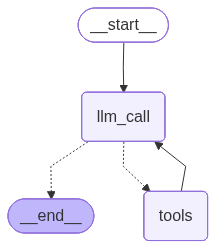

================================ Human Message =================================

What is (2 + 3) times 4? Use the calculator.
================================== Ai Message ==================================
Tool Calls:
  calculator (pqqyawvff)
 Call ID: pqqyawvff
  Args:
    expression: (2 + 3) * 4
================================= Tool Message =================================
Name: calculator

20
================================== Ai Message ==================================

The answer is 20.


In [26]:
builder2 = StateGraph(MessagesState)
builder2.add_node("llm_call", llm_call_prebuilt)
builder2.add_node("tools", tool_node)
builder2.add_edge(START, "llm_call")
builder2.add_conditional_edges("llm_call", should_continue_prebuilt, ["tools", END])
builder2.add_edge("tools", "llm_call")

agent2 = builder2.compile()
save_graph(agent2, "12_agent_toolnode")
show_graph("12_agent_toolnode")

out = agent2.invoke({"messages": [HumanMessage(content="What is (2 + 3) times 4? Use the calculator.")]})
for m in out["messages"]:
    m.pretty_print()


In [27]:
eval("2 + 3")

5

In [29]:
import ast
import operator
import logging

logger = logging.getLogger(__name__)

SAFE_OPERATORS = {
    ast.Add:  operator.add,
    ast.Sub:  operator.sub,
    ast.Mult: operator.mul,
    ast.Div:  operator.truediv,
    ast.Pow:  operator.pow,
    ast.USub: operator.neg,   # handles negative numbers like -5
}


def safe_eval(expression: str) -> float:
    """Safely evaluate a math expression. Raises ValueError for unsupported ops."""
    def _eval(node):
        if isinstance(node, ast.Constant) and isinstance(node.value, (int, float)):
            return node.value
        if isinstance(node, ast.BinOp) and type(node.op) in SAFE_OPERATORS:
            return SAFE_OPERATORS[type(node.op)](_eval(node.left), _eval(node.right))
        if isinstance(node, ast.UnaryOp) and type(node.op) in SAFE_OPERATORS:
            return SAFE_OPERATORS[type(node.op)](_eval(node.operand))
        raise ValueError(f"Unsupported expression: {ast.dump(node)}")

    try:
        result = _eval(ast.parse(expression, mode="eval").body)
        logger.debug("safe_eval: %s = %s", expression, result)
        return result
    except ZeroDivisionError:
        raise ValueError("Division by zero is not allowed")
    except (KeyError, TypeError) as e:
        raise ValueError(f"Invalid expression: {e}")

In [30]:
# Normal cases — should work
print(safe_eval("2 + 3"))          # 5
print(safe_eval("2 + 3 * 4"))      # 14  (respects precedence)
print(safe_eval("10 / 2"))         # 5.0
print(safe_eval("2 ** 3"))         # 8   (power)
print(safe_eval("-5 + 3"))         # -2  (negative number)


5
14
5.0
8
-2


In [ ]:
#Attack cases — should raise ValueError, NOT execute
print(safe_eval("__import__('os').system('ls')"))   # ValueError
print(safe_eval("'hello' + 'world'"))               # ValueError (string)
print(safe_eval("10 / 0"))                          # ValueError (division by zero)
print(safe_eval("open('secret.txt').read()"))       # ValueError

**safe_eval()**:

It is mainly used in #agents/#tools when the #LLM needs to perform calculations safely.

**Functional API agent**

In [33]:
import logging
from langgraph.func import entrypoint, task
from langgraph.graph import add_messages
from langchain_core.messages import BaseMessage, SystemMessage

logger = logging.getLogger(__name__)

SYSTEM_PROMPT = "You are a helpful assistant performing arithmetic."


@task
def call_llm(messages: list[BaseMessage]) -> BaseMessage:
    return llm_with_tools.invoke(
        [SystemMessage(content=SYSTEM_PROMPT)] + messages
    )


@task
def call_tool(tool_call: dict) -> BaseMessage:
    tool = tools_by_name[tool_call["name"]]
    result = tool.invoke(tool_call)
    logger.debug("Tool: %s | Args: %s | Result: %s", tool_call["name"], tool_call["args"], result)
    return result


@entrypoint()
def agent_func(messages: list[BaseMessage]) -> list[BaseMessage]:
    llm_response = call_llm(messages).result()

    while llm_response.tool_calls:
        logger.debug("Tool calls: %s", [tc["name"] for tc in llm_response.tool_calls])
        #run ALL requested tools in parallel
        tool_results = [call_tool(tc).result() for tc in llm_response.tool_calls]

        #add what LLM said + tool results back to conversation history
        messages = add_messages(messages, [llm_response, *tool_results])

        #LLM looks at full history including tool results
        llm_response = call_llm(messages).result()

    logger.info("Agent finished | Final response: %.80s", llm_response.content)
    return add_messages(messages, llm_response)


# --- Run ---
for chunk in agent_func.stream(
    [HumanMessage(content="Add 3 and 4.")],
    stream_mode="updates"
):
    print(chunk)

{'call_llm': AIMessage(content='', additional_kwargs={'tool_calls': [{'id': '9pfbgjvpf', 'function': {'arguments': '{"a":3,"b":4}', 'name': 'add'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 18, 'prompt_tokens': 337, 'total_tokens': 355, 'completion_time': 0.040382511, 'completion_tokens_details': None, 'prompt_time': 0.017385024, 'prompt_tokens_details': None, 'queue_time': 0.047481357, 'total_time': 0.057767535}, 'model_name': 'llama-3.3-70b-versatile', 'system_fingerprint': 'fp_d42c28f9ce', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019e9252-486b-7ef3-979c-7799fd95dcb6-0', tool_calls=[{'name': 'add', 'args': {'a': 3, 'b': 4}, 'id': '9pfbgjvpf', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 337, 'output_tokens': 18, 'total_tokens': 355})}
{'call_tool': ToolMessage(content='7', name='add', tool_call_id='9pfbgjvpf')}
{'call_llm': AIMessage(conten